# 🚀 Обучение на Аудио Конволюционната Мрежа (Model 2)

В този ноутбук ще извършим същинското обучение на нашия модел `AudioCNN` върху набора от данни ESC-50. 
Процесът включва:
1. Зареждане на данните чрез създадения `ESC50Dataset`.
2. Дефиниране на хиперпараметрите, функцията на загуба (Loss Function) и оптимизатора.
3. Изпълнение на Тренировъчния цикъл с проследяване на точността върху Валидационния сет.
4. Запазване на най-добрите тегла (weights) на модела.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Импорт на нашите модули
from src.data_processing.splitting import split_data
from src.data_processing.esc50_dataset import ESC50Dataset
from src.models.CNN_model import AudioCNN

# Настройка на устройството (GPU за Nvidia, MPS за Mac M1/M2, или CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Моделът ще се обучава на: {device}")

# Пътища
CSV_PATH = "../data/raw/ESC-50-master/meta/esc50.csv"
AUDIO_DIR = "../data/raw/ESC-50-master/audio/"
MODEL_SAVE_PATH = "../models/audiocnn_model1.pth" # Папка за запазване на модела

# Създаване на папка, ако не съществува
os.makedirs("../models", exist_ok=True)

Моделът ще се обучава на: mps


## 1. Инициализация на Данните (DataLoaders)
Зареждаме данните на партиди (batches) от по 32 спектрограми. Използваме предварително разделени Train и Validation набори.

In [2]:
# Разделяне на метаданните
train_df, val_df, test_df = split_data(CSV_PATH)

# Инициализиране на Dataset обектите
print("Зареждане на тренировъчни данни...")
train_dataset = ESC50Dataset(train_df, AUDIO_DIR)
encoder = train_dataset.label_encoder # Запазваме енкодера

print("Зареждане на валидационни данни...")
val_dataset = ESC50Dataset(val_df, AUDIO_DIR, label_encoder=encoder)

# Създаване на DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Тренировъчни бачове: {len(train_loader)} | Валидационни бачове: {len(val_loader)}")

Зареждане на тренировъчни данни...
Зареждане на валидационни данни...
Тренировъчни бачове: 38 | Валидационни бачове: 13


## 2. Инстанциране на Модела, Loss и Оптимизатор
* **Модел:** Нашият `AudioCNN` с 50 изходни класа.
* **Loss Function:** `CrossEntropyLoss` – стандарт за многокласова класификация. Тя автоматично включва Softmax.
* **Оптимизатор:** `Adam` с Learning Rate от $0.001$.

In [ ]:
# Инициализация на модела
model = AudioCNN(n_classes=50).to(device)

# Дефиниране на Loss и Оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# УМНАТА ЧАСТ: Добавяме Scheduler
# Ако val_loss не пада 5 епохи поред, намалява Learning Rate-а наполовина (factor=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Хиперпараметри за обучението
EPOCHS = 100               # Вече спокойно можем да сложим 100 епохи
best_val_loss = float('inf')
patience = 15              # Колко епохи да чакаме преди да спрем тренировката
patience_counter = 0       # Брояч за лоши епохи

# Списъци за пазене на историята
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

## 3. Същински Тренировъчен Цикъл (The Training Loop)
Този цикъл преминава през данните множество пъти (Епохи). Във всяка епоха има две фази:
1. **Train:** Моделът прави прогнози, изчислява грешката си и обновява теглата си (Backpropagation).
2. **Validation:** Моделът се тества върху невиждани данни, без да се обновява (за да следим за Overfitting).
Ако валидационната грешка е най-ниската досега, запазваме модела.

In [4]:
for epoch in range(EPOCHS):
    model.train() # Включва Dropout и BatchNorm
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # tqdm прави красива лента за зареждане
    for inputs, labels in tqdm(train_loader, desc=f"Епоха {epoch+1}/{EPOCHS} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad() # Зануляваме старите градиенти
        
        outputs = model(inputs) # Прав ход (Forward pass)
        loss = criterion(outputs, labels) # Изчисляване на грешката
        
        loss.backward() # Обратен ход (Backpropagation)
        optimizer.step() # Обновяване на теглата
        
        running_loss += loss.item()
        
        # Изчисляване на точността
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train
    
    # =========================
    # ФАЗА: ВАЛИДАЦИЯ (VALIDATION)
    # =========================
    model.eval() # Изключва Dropout, за да е обективен теста
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # Изключваме изчисляването на градиенти (пести памет)
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val
    
    # Запазване на историята
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Резултати: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% || Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Запазване на най-добрия модел
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"🌟 Нов най-добър модел е запазен! (Val Loss: {best_val_loss:.4f})")
    print("-" * 60)

print("🎉 Обучението приключи!")

Епоха 1/30 [Train]: 100%|██████████| 38/38 [00:12<00:00,  2.95it/s]


Резултати: Train Loss: 3.8540 | Train Acc: 3.58% || Val Loss: 3.8270 | Val Acc: 5.00%
🌟 Нов най-добър модел е запазен! (Val Loss: 3.8270)
------------------------------------------------------------


Епоха 2/30 [Train]: 100%|██████████| 38/38 [00:06<00:00,  5.76it/s]


Резултати: Train Loss: 3.6796 | Train Acc: 7.50% || Val Loss: 3.5589 | Val Acc: 10.25%
🌟 Нов най-добър модел е запазен! (Val Loss: 3.5589)
------------------------------------------------------------


Епоха 3/30 [Train]: 100%|██████████| 38/38 [00:06<00:00,  5.79it/s]


...

Резултати: Train Loss: 2.1130 | Train Acc: 35.25% || Val Loss: 2.9507 | Val Acc: 19.00%
------------------------------------------------------------


Епоха 29/30 [Train]: 100%|██████████| 38/38 [00:06<00:00,  6.18it/s]


Резултати: Train Loss: 2.1625 | Train Acc: 34.08% || Val Loss: 2.9343 | Val Acc: 24.50%
------------------------------------------------------------


Епоха 30/30 [Train]: 100%|██████████| 38/38 [00:06<00:00,  6.24it/s]


Резултати: Train Loss: 2.0725 | Train Acc: 36.75% || Val Loss: 2.7126 | Val Acc: 23.25%
------------------------------------------------------------
🎉 Обучението приключи!


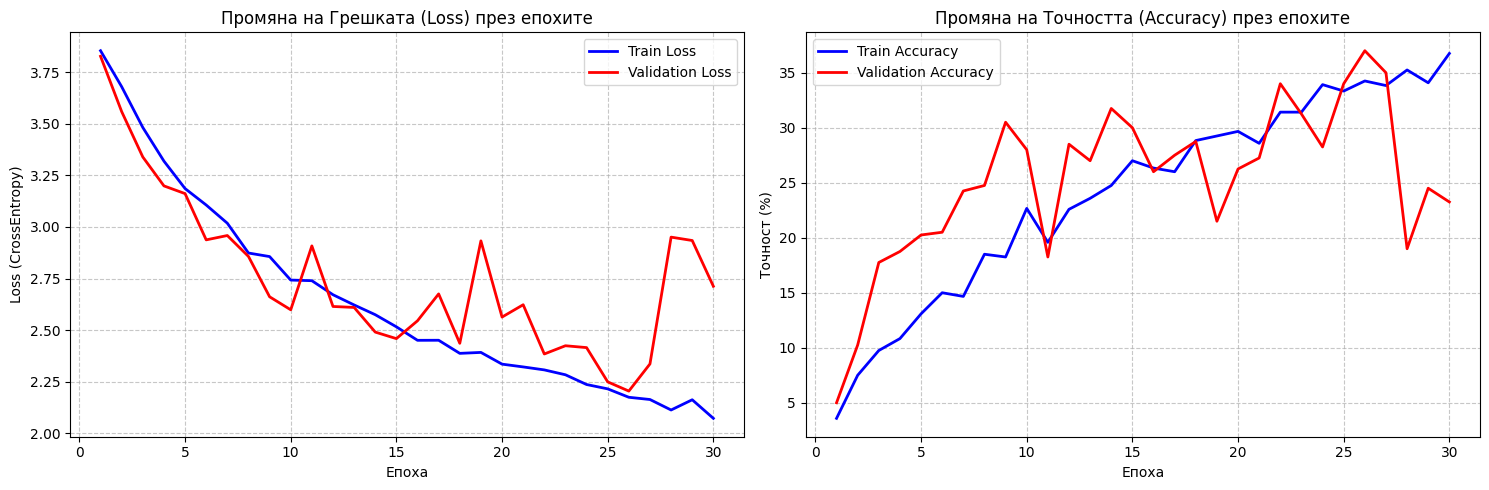

In [5]:
# КЛЕТКА 5: Визуализация на резултатите от обучението
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Графика 1: Грешка (Loss)
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[0].set_title('Промяна на Грешката (Loss) през епохите')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss (CrossEntropy)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Графика 2: Точност (Accuracy)
axes[1].plot(epochs_range, history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='red', linewidth=2)
axes[1].set_title('Промяна на Точността (Accuracy) през епохите')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Точност (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()